# Sentiment Analysis on Movie Reviews (PyTorch)
**BeeNeural Intern Portal — Data Science & Analytics Task**

**Goal:** classify movie reviews as **negative, neutral or positive** with a PyTorch model.

**Approach:** Stanford Sentiment Treebank (SST-5) movie-review sentences, collapsed from 5 labels to 3 classes, then a Bidirectional LSTM with masked mean+max pooling trained from scratch.

**Pipeline:** load data -> tokenize -> build vocabulary -> encode/pad -> BiLSTM -> train with early stopping -> evaluate (accuracy, F1, confusion matrix) -> efficiency measurements -> predict on new reviews.

In [1]:
!pip -q install datasets

In [2]:
import re, random, time, collections
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 1. Dataset
SST-5 has five labels (0 very negative ... 4 very positive). They are merged into three classes:

| Original | New class |
|---|---|
| 0, 1 | negative (0) |
| 2 | neutral (1) |
| 3, 4 | positive (2) |

In [3]:
raw = load_dataset("SetFit/sst5")
print(raw)

CLASS_NAMES = ["negative", "neutral", "positive"]
def to3(l):
    return 0 if l in (0, 1) else (1 if l == 2 else 2)

splits = {}
for name, key in [("train", "train"), ("val", "validation"), ("test", "test")]:
    texts = list(raw[key]["text"])
    labels = [to3(l) for l in raw[key]["label"]]
    splits[name] = (texts, labels)
    counts = collections.Counter(labels)
    print(name, len(texts), {CLASS_NAMES[k]: counts[k] for k in sorted(counts)})

README.md:   0%|          | 0.00/421 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/1.32M [00:00<?, ?B/s]

dev.jsonl:   0%|          | 0.00/171k [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/343k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8544 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1101 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2210 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 8544
    })
    validation: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1101
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 2210
    })
})
train 8544 {'negative': 3310, 'neutral': 1624, 'positive': 3610}
val 1101 {'negative': 428, 'neutral': 229, 'positive': 444}
test 2210 {'negative': 912, 'neutral': 389, 'positive': 909}


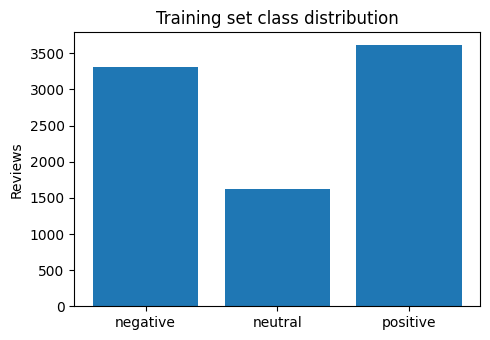

In [4]:
counts = collections.Counter(splits["train"][1])
plt.figure(figsize=(5, 3.5))
plt.bar(CLASS_NAMES, [counts[i] for i in range(3)])
plt.title("Training set class distribution"); plt.ylabel("Reviews")
plt.tight_layout(); plt.savefig("class_distribution.png", dpi=150); plt.show()

## 2. Text preprocessing
- lowercase
- keep words, numbers, apostrophes and the sentiment-carrying tokens `!` and `?`
- vocabulary built from the **training set only** (words seen at least twice); everything else becomes `<unk>`
- sequences padded / truncated to a fixed length

In [5]:
def tokenize(text):
    return re.findall(r"[a-z0-9']+|[!?]", text.lower())

PAD, UNK = 0, 1
MIN_FREQ, MAX_LEN = 2, 60

freq = collections.Counter(tok for t in splits["train"][0] for tok in tokenize(t))
itos = ["<pad>", "<unk>"] + [w for w, c in freq.most_common() if c >= MIN_FREQ]
stoi = {w: i for i, w in enumerate(itos)}
print("Vocabulary size:", len(itos))

lens = [len(tokenize(t)) for t in splits["train"][0]]
print("Token length: mean %.1f, 95th percentile %d, max %d" % (np.mean(lens), np.percentile(lens, 95), max(lens)))

def encode(text):
    ids = [stoi.get(tok, UNK) for tok in tokenize(text)][:MAX_LEN]
    return ids + [PAD] * (MAX_LEN - len(ids))

def make_loader(name, batch_size, shuffle):
    texts, labels = splits[name]
    X = torch.tensor([encode(t) for t in texts], dtype=torch.long)
    y = torch.tensor(labels, dtype=torch.long)
    return DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=shuffle)

BATCH = 64
train_dl = make_loader("train", BATCH, True)
val_dl = make_loader("val", 256, False)
test_dl = make_loader("test", 256, False)
print("Batches:", len(train_dl), len(val_dl), len(test_dl))

Vocabulary size: 8234
Token length: mean 17.5, 95th percentile 33, max 49
Batches: 134 5 9


## 3. Model
**Embedding -> Bidirectional LSTM -> masked mean + max pooling -> dropout -> linear (3 classes)**

- `pack_padded_sequence` so padding never affects the LSTM states
- mean and max pooling over all time steps (ignoring padding) capture both overall tone and strongest sentiment words
- dropout (0.5) and weight decay reduce over-fitting, which matters for a small dataset

In [6]:
class SentimentBiLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden=128, n_classes=3, dropout=0.5):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.lstm = nn.LSTM(emb_dim, hidden, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 4, n_classes)

    def forward(self, x):
        mask = (x != PAD)
        lengths = mask.sum(1).clamp(min=1).cpu()
        e = self.drop(self.emb(x))
        packed = pack_padded_sequence(e, lengths, batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(out, batch_first=True, total_length=x.size(1))
        m = mask.unsqueeze(-1)
        mean = (out * m).sum(1) / m.sum(1).clamp(min=1)
        mx = out.masked_fill(~m, -1e9).max(1).values
        return self.fc(self.drop(torch.cat([mean, mx], dim=1)))

model = SentimentBiLSTM(len(itos)).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print("Trainable parameters: {:,}".format(n_params))

SentimentBiLSTM(
  (emb): Embedding(8234, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (drop): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=3, bias=True)
)
Trainable parameters: 1,319,683


## 4. Training
- Adam optimizer, learning-rate reduction when validation accuracy stalls
- class-weighted cross-entropy because the neutral class is smaller
- gradient clipping for stable LSTM training
- early stopping: the best model on the **validation** set is kept

In [7]:
EPOCHS, LR, PATIENCE = 15, 2e-3, 4

cls_counts = torch.tensor([counts[i] for i in range(3)], dtype=torch.float)
weights = (cls_counts.sum() / (3 * cls_counts)).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

def run_epoch(dl, train):
    model.train(train)
    total_loss, preds, gold = 0.0, [], []
    with torch.set_grad_enabled(train):
        for X, y in dl:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            preds += logits.argmax(1).cpu().tolist()
            gold += y.cpu().tolist()
    return total_loss / len(gold), accuracy_score(gold, preds)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_acc, best_state, bad = 0.0, None, 0
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    tl, ta = run_epoch(train_dl, True)
    vl, va = run_epoch(val_dl, False)
    scheduler.step(va)
    for k, v in zip(history, (tl, vl, ta, va)):
        history[k].append(v)
    print("Epoch %2d | train loss %.4f acc %.4f | val loss %.4f acc %.4f" % (epoch, tl, ta, vl, va))
    if va > best_acc:
        best_acc, bad = va, 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        bad += 1
        if bad >= PATIENCE:
            print("Early stopping.")
            break
train_time = time.time() - t0
model.load_state_dict(best_state)
print("Best validation accuracy: %.4f | training time: %.1f s" % (best_acc, train_time))

Epoch  1 | train loss 1.0901 acc 0.3970 | val loss 1.0306 acc 0.4923
Epoch  2 | train loss 1.0394 acc 0.4768 | val loss 1.0157 acc 0.5704
Epoch  3 | train loss 0.9812 acc 0.5378 | val loss 0.9660 acc 0.5186
Epoch  4 | train loss 0.9174 acc 0.5802 | val loss 0.9266 acc 0.5441
Epoch  5 | train loss 0.8340 acc 0.6430 | val loss 0.9472 acc 0.5704
Epoch  6 | train loss 0.7870 acc 0.6626 | val loss 0.9871 acc 0.6194
Epoch  7 | train loss 0.7476 acc 0.6841 | val loss 0.9811 acc 0.5677
Epoch  8 | train loss 0.7082 acc 0.7037 | val loss 1.0407 acc 0.5940
Epoch  9 | train loss 0.6659 acc 0.7259 | val loss 1.0679 acc 0.5840
Epoch 10 | train loss 0.6363 acc 0.7449 | val loss 1.0841 acc 0.5668
Early stopping.
Best validation accuracy: 0.6194 | training time: 263.0 s


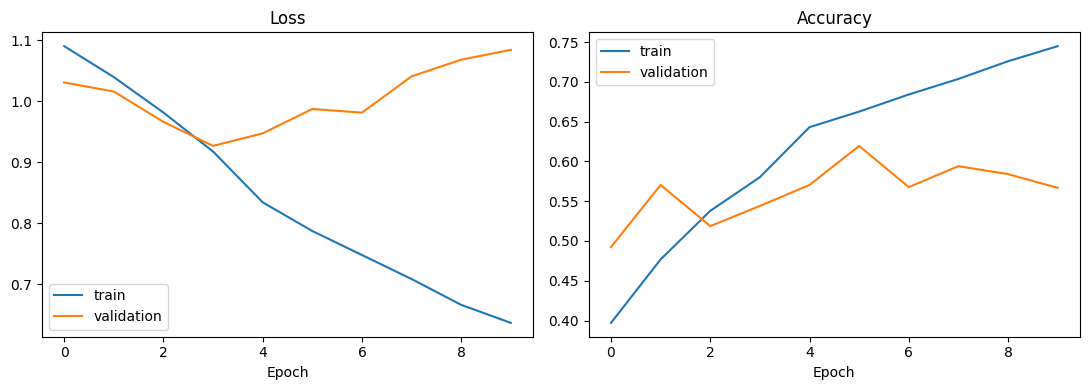

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="validation")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(history["train_acc"], label="train"); ax[1].plot(history["val_acc"], label="validation")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig("training_curves.png", dpi=150); plt.show()

## 5. Evaluation on the test set
The test set was not used for training, early stopping or any tuning decision.

In [9]:
model.eval()
preds, gold = [], []
t0 = time.time()
with torch.no_grad():
    for X, y in test_dl:
        preds += model(X.to(device)).argmax(1).cpu().tolist()
        gold += y.tolist()
infer_time = time.time() - t0

test_acc = accuracy_score(gold, preds)
macro_f1 = f1_score(gold, preds, average="macro")
print("Test accuracy: %.4f | macro F1: %.4f" % (test_acc, macro_f1))
print()
print(classification_report(gold, preds, target_names=CLASS_NAMES, digits=4))
print("Inference speed: %.0f reviews/second on %s" % (len(gold) / infer_time, device))

Test accuracy: 0.6317 | macro F1: 0.5600

              precision    recall  f1-score   support

    negative     0.6331    0.7303    0.6782       912
     neutral     0.3046    0.2545    0.2773       389
    positive     0.7575    0.6942    0.7245       909

    accuracy                         0.6317      2210
   macro avg     0.5651    0.5596    0.5600      2210
weighted avg     0.6264    0.6317    0.6267      2210

Inference speed: 1911 reviews/second on cpu


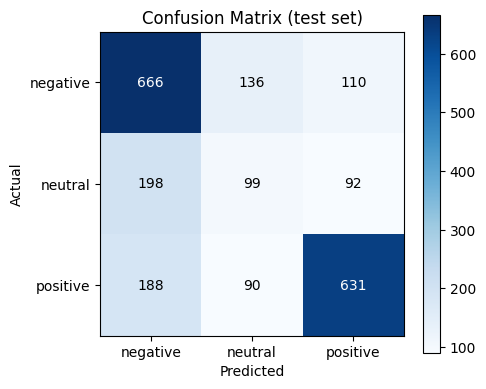

In [10]:
cm = confusion_matrix(gold, preds)
plt.figure(figsize=(5, 4.2))
plt.imshow(cm, cmap="Blues"); plt.colorbar()
plt.xticks(range(3), CLASS_NAMES); plt.yticks(range(3), CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix (test set)")
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150); plt.show()

## 6. Efficiency summary

In [11]:
print("Parameters          : {:,}".format(n_params))
print("Training time       : %.1f s (%d epochs, device: %s)" % (train_time, len(history["train_loss"]), device))
print("Inference throughput: %.0f reviews/s" % (len(gold) / infer_time))
print("Model size on disk  : ~%.1f MB" % (n_params * 4 / 1e6))

Parameters          : 1,319,683
Training time       : 263.0 s (10 epochs, device: cpu)
Inference throughput: 1911 reviews/s
Model size on disk  : ~5.3 MB


## 7. Predicting new reviews

In [12]:
def predict(text):
    model.eval()
    x = torch.tensor([encode(text)], dtype=torch.long).to(device)
    with torch.no_grad():
        p = torch.softmax(model(x), dim=1)[0].cpu()
    return CLASS_NAMES[int(p.argmax())], p.tolist()

samples = [
    "An absolutely brilliant film with stunning performances and a moving story.",
    "A dull, predictable mess that wastes a talented cast.",
    "The movie is about two hours long and set in a small town.",
    "Not good at all, I want my money back!",
]
for s in samples:
    label, probs = predict(s)
    print("%-10s %s  (neg %.2f / neu %.2f / pos %.2f)" % (label, s, *probs))

positive   An absolutely brilliant film with stunning performances and a moving story.  (neg 0.00 / neu 0.00 / pos 1.00)
negative   A dull, predictable mess that wastes a talented cast.  (neg 0.72 / neu 0.19 / pos 0.09)
negative   The movie is about two hours long and set in a small town.  (neg 0.75 / neu 0.19 / pos 0.06)
neutral    Not good at all, I want my money back!  (neg 0.30 / neu 0.65 / pos 0.05)


In [13]:
import json
torch.save({"model_state": model.state_dict(), "itos": itos, "max_len": MAX_LEN, "classes": CLASS_NAMES}, "sentiment_bilstm.pt")
print("Saved sentiment_bilstm.pt")

Saved sentiment_bilstm.pt
